# Draft 3: Manual ML Fraud Detection

This notebook is a fully local workflow for Kaggle 01. It does not use Kaggle API, AutoML, or auto submission.


## Goal

- Load `train.csv`, `test.csv`, and `sample_submission.csv` from the local `data/` folder
- Check class imbalance and missing values
- Build fraud-focused features
- Compare a few manual models
- Tune the threshold for macro F1
- Export a CSV for manual submission

The data is very imbalanced, so accuracy is not the main focus. We will optimize for macro F1.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

NOTEBOOK_DIR_NAME = "kaggle/01-fraudulent-transaction-detect"
candidate_base_dirs = [
    Path.cwd(),
    Path.cwd() / NOTEBOOK_DIR_NAME,
    Path(
        "/Users/beam/Workspace/Course/my-cpe-lab/Y2/CPE232/kaggle/01-fraudulent-transaction-detect"
    ),
]
BASE_DIR = next(
    (
        candidate
        for candidate in candidate_base_dirs
        if (candidate / "data" / "train.csv").exists()
    ),
    None,
)
if BASE_DIR is None:
    raise FileNotFoundError(
        "Could not find the Kaggle 01 data folder from the current working directory"
    )

DATA_DIR = BASE_DIR / "data"
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_PATH = DATA_DIR / "sample_submission.csv"
OUTPUT_PATH = BASE_DIR / "submission_manual_ml.csv"

ID_COL = "id"
LABEL_COL = "is_fraud"
TIME_COL = "time_ind"
RANDOM_STATE = 42
PRIMARY_VALID_SIZE = 0.20
TIME_VALID_FRACTION = 0.15
THRESHOLD_GRID = np.round(np.arange(0.01, 0.96, 0.01), 2)
MODEL_NEGATIVE_CAPS = {
    "logistic_regression": 300_000,
    "random_forest": 200_000,
    "hist_gradient_boosting": 600_000,
}
FINAL_NEGATIVE_CAPS = {
    "logistic_regression": None,
    "random_forest": 300_000,
    "hist_gradient_boosting": None,
}

print("Base directory:", BASE_DIR)
print("Data directory:", DATA_DIR)
print("Output file:", OUTPUT_PATH)


Base directory: /Users/beam/Workspace/Course/my-cpe-lab/Y2/CPE232/kaggle/01-fraudulent-transaction-detect
Data directory: /Users/beam/Workspace/Course/my-cpe-lab/Y2/CPE232/kaggle/01-fraudulent-transaction-detect/data
Output file: /Users/beam/Workspace/Course/my-cpe-lab/Y2/CPE232/kaggle/01-fraudulent-transaction-detect/submission_manual_ml.csv


In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)

train_df.head()


Train shape: (5408227, 12)
Test shape: (954393, 11)
Sample submission shape: (954393, 2)


,id,time_ind,transac_type,amount,src_acc,src_bal,src_new_bal,dst_acc,dst_bal,dst_new_bal,is_fraud,is_flagged_fraud
0,0,355,CASH_OUT,"56,964.5700",acc4649128,"20,090.0000",0.0000,acc8350663,0.0000,"56,964.5700",0,0
1,1,284,CASH_OUT,"108,454.3700",acc6660911,505.0000,0.0000,acc1547749,0.0000,"108,454.3700",0,0
2,2,378,NaN,"467,324.3300",acc7810035,"1,634.0000",0.0000,acc3033156,"258,071.6100","725,395.9500",0,0
3,3,129,CASH_IN,"274,154.9700",acc4833344,"3,171,570.2000","3,445,725.1700",acc5071405,"1,692,712.5800","987,166.6000",0,0
4,4,217,PAYMENT,NaN,acc8839024,"23,231.0900",0.0000,acc6776502,0.0000,0.0000,0,0


In [4]:
expected_train_cols = {
    "id",
    "time_ind",
    "transac_type",
    "amount",
    "src_acc",
    "src_bal",
    "src_new_bal",
    "dst_acc",
    "dst_bal",
    "dst_new_bal",
    "is_fraud",
    "is_flagged_fraud",
}
expected_test_cols = expected_train_cols - {LABEL_COL}

assert set(train_df.columns) == expected_train_cols, (
    "Train columns do not match expectation"
)
assert set(test_df.columns) == expected_test_cols, (
    "Test columns do not match expectation"
)
assert LABEL_COL not in test_df.columns, "Test must not contain the target"
assert train_df[ID_COL].is_unique, "Train IDs must be unique"
assert test_df[ID_COL].is_unique, "Test IDs must be unique"
assert sample_submission.columns.tolist() == [ID_COL, LABEL_COL], (
    "Unexpected submission columns"
)
assert (
    train_df.drop(columns=[LABEL_COL]).columns.tolist() == test_df.columns.tolist()
), "Train and test feature columns must align"

print("All schema checks passed")


All schema checks passed


## Fast EDA

We will keep this part short. The goal is to understand which patterns matter for fraud detection and which features may be risky to use directly.


Target counts


,rows
is_fraud,
0,5401246
1,6981


Target ratio


,ratio
is_fraud,
0,0.9987
1,0.0013


Missing summary


...

is_fraud,non_fraud_rate,fraud_rate
transac_type,,
CASH_IN,1.0000,0.0000
CASH_OUT,0.9983,0.0017
DEBIT,1.0000,0.0000
MISSING,0.9977,0.0023
PAYMENT,1.0000,0.0000
TRANSFER,0.9923,0.0077


Flagged fraud vs actual fraud


is_fraud,0,1
is_flagged_fraud,,
0,5401246,6965
1,0,16


Highest fraud-rate time steps


,count,sum,fraud_rate
time_ind,,,
743,7,7,1.0000
606,12,12,1.0000
272,8,8,1.0000
271,9,9,1.0000
270,14,14,1.0000
269,14,14,1.0000
268,4,4,1.0000
579,12,12,1.0000
581,10,10,1.0000


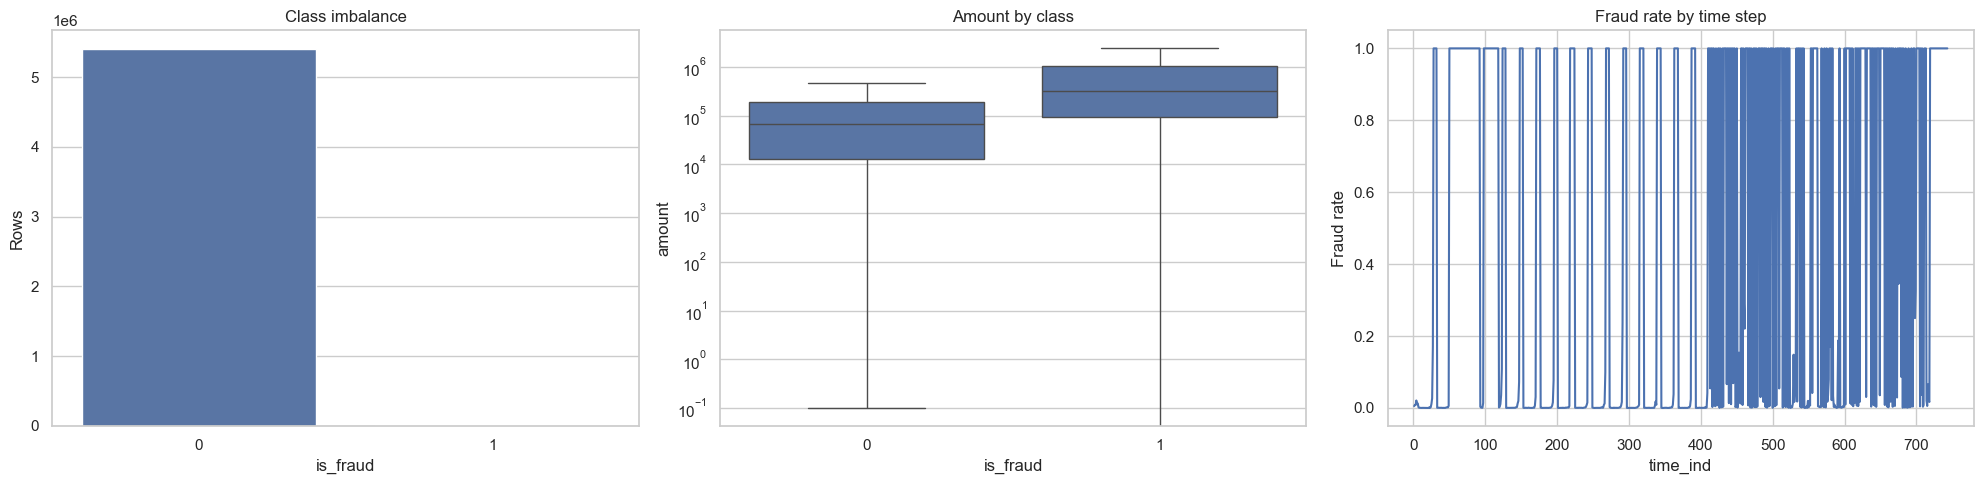

In [5]:
target_counts = train_df[LABEL_COL].value_counts().sort_index()
target_ratio = train_df[LABEL_COL].value_counts(normalize=True).sort_index()
missing_summary = pd.DataFrame(
    {
        "train_missing": train_df.isna().sum(),
        "train_missing_pct": train_df.isna().mean() * 100,
        "test_missing": test_df.isna().sum(),
        "test_missing_pct": test_df.isna().mean() * 100,
    }
).sort_values("train_missing", ascending=False)

fraud_by_type = pd.crosstab(
    train_df["transac_type"].fillna("MISSING"),
    train_df[LABEL_COL],
    normalize="index",
).rename(columns={0: "non_fraud_rate", 1: "fraud_rate"})

fraud_by_flag = pd.crosstab(train_df["is_flagged_fraud"], train_df[LABEL_COL])
fraud_by_time = train_df.groupby(TIME_COL, observed=True)[LABEL_COL].agg(
    ["count", "sum"]
)
fraud_by_time["fraud_rate"] = fraud_by_time["sum"] / fraud_by_time["count"]

print("Target counts")
display(target_counts.to_frame("rows"))
print("Target ratio")
display(target_ratio.to_frame("ratio"))
print("Missing summary")
display(missing_summary)
print("Fraud rate by transaction type")
display(fraud_by_type)
print("Flagged fraud vs actual fraud")
display(fraud_by_flag)
print("Highest fraud-rate time steps")
display(fraud_by_time.sort_values("fraud_rate", ascending=False).head(10))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.barplot(x=target_counts.index.astype(str), y=target_counts.values, ax=axes[0])
axes[0].set_title("Class imbalance")
axes[0].set_xlabel(LABEL_COL)
axes[0].set_ylabel("Rows")

amount_plot = train_df[["amount", LABEL_COL]].dropna().copy()
amount_plot = amount_plot.sample(
    min(len(amount_plot), 200_000), random_state=RANDOM_STATE
)
sns.boxplot(data=amount_plot, x=LABEL_COL, y="amount", ax=axes[1], showfliers=False)
axes[1].set_title("Amount by class")
axes[1].set_yscale("log")

sns.lineplot(data=fraud_by_time.reset_index(), x=TIME_COL, y="fraud_rate", ax=axes[2])
axes[2].set_title("Fraud rate by time step")
axes[2].set_ylabel("Fraud rate")

plt.tight_layout()
plt.show()


**EDA notes**

- The dataset is extremely imbalanced, so a model can look good on accuracy and still miss fraud.
- Fraud appears only in some transaction types, so transaction-type features matter.
- `is_flagged_fraud` is useful, but it only catches a very small part of the fraud cases.
- `src_acc` and `dst_acc` are too high-cardinality to one-hot directly, so we will turn them into compact count features instead.


In [6]:
def make_time_holdout(df, valid_fraction=TIME_VALID_FRACTION):
    unique_steps = np.sort(df[TIME_COL].unique())
    n_valid_steps = max(1, int(np.ceil(len(unique_steps) * valid_fraction)))
    valid_steps = unique_steps[-n_valid_steps:]
    valid_mask = df[TIME_COL].isin(valid_steps)
    train_part = df.loc[~valid_mask].copy()
    valid_part = df.loc[valid_mask].copy()

    assert train_part[LABEL_COL].nunique() == 2, (
        "Time split train must contain both classes"
    )
    assert valid_part[LABEL_COL].nunique() == 2, (
        "Time split valid must contain both classes"
    )
    return train_part, valid_part


def build_feature_artifacts(fit_df):
    transac_clean = fit_df["transac_type"].fillna("MISSING")
    numeric_cols = ["amount", "src_bal", "src_new_bal", "dst_bal", "dst_new_bal"]
    medians = {col: float(fit_df[col].median()) for col in numeric_cols}
    src_count_map = fit_df["src_acc"].value_counts().to_dict()
    dst_count_map = fit_df["dst_acc"].value_counts().to_dict()
    fraud_only = fit_df.loc[fit_df[LABEL_COL] == 1]
    src_fraud_count_map = fraud_only["src_acc"].value_counts().to_dict()
    dst_fraud_count_map = fraud_only["dst_acc"].value_counts().to_dict()
    late_step_cutoff = int(fit_df[TIME_COL].quantile(0.85))

    return {
        "medians": medians,
        "src_count_map": src_count_map,
        "dst_count_map": dst_count_map,
        "src_fraud_count_map": src_fraud_count_map,
        "dst_fraud_count_map": dst_fraud_count_map,
        "late_step_cutoff": late_step_cutoff,
        "type_levels": [
            "CASH_IN",
            "CASH_OUT",
            "DEBIT",
            "PAYMENT",
            "TRANSFER",
            "MISSING",
        ],
    }


def make_feature_frame(df, artifacts):
    frame = pd.DataFrame(index=df.index)
    medians = artifacts["medians"]
    transac_clean = df["transac_type"].fillna("MISSING")

    amount_filled = df["amount"].fillna(medians["amount"])
    src_bal_filled = df["src_bal"].fillna(medians["src_bal"])
    src_new_bal_filled = df["src_new_bal"].fillna(medians["src_new_bal"])
    dst_bal_filled = df["dst_bal"].fillna(medians["dst_bal"])
    dst_new_bal_filled = df["dst_new_bal"].fillna(medians["dst_new_bal"])

    frame["time_ind"] = df[TIME_COL].astype("float32")
    frame["amount"] = amount_filled.astype("float32")
    frame["src_bal"] = src_bal_filled.astype("float32")
    frame["src_new_bal"] = src_new_bal_filled.astype("float32")
    frame["dst_bal"] = dst_bal_filled.astype("float32")
    frame["dst_new_bal"] = dst_new_bal_filled.astype("float32")
    frame["is_flagged_fraud"] = df["is_flagged_fraud"].astype("float32")

    frame["amount_missing"] = df["amount"].isna().astype("float32")
    frame["src_bal_missing"] = df["src_bal"].isna().astype("float32")
    frame["dst_bal_missing"] = df["dst_bal"].isna().astype("float32")
    frame["transac_type_missing"] = df["transac_type"].isna().astype("float32")

    frame["log_amount"] = np.log1p(amount_filled).astype("float32")
    frame["src_delta"] = (src_bal_filled - src_new_bal_filled).astype("float32")
    frame["dst_delta"] = (dst_new_bal_filled - dst_bal_filled).astype("float32")
    frame["src_balance_error"] = (
        np.abs(src_bal_filled - src_new_bal_filled - amount_filled)
    ).astype("float32")
    frame["dst_balance_error"] = (
        np.abs(dst_new_bal_filled - dst_bal_filled - amount_filled)
    ).astype("float32")
    frame["amount_to_src_ratio"] = (
        amount_filled / (np.abs(src_bal_filled) + 1.0)
    ).astype("float32")
    frame["amount_to_dst_ratio"] = (
        amount_filled / (np.abs(dst_bal_filled) + 1.0)
    ).astype("float32")

    frame["src_zero_before"] = (src_bal_filled == 0).astype("float32")
    frame["src_zero_after"] = (src_new_bal_filled == 0).astype("float32")
    frame["dst_zero_before"] = (dst_bal_filled == 0).astype("float32")
    frame["dst_zero_after"] = (dst_new_bal_filled == 0).astype("float32")
    frame["source_emptied_flag"] = (
        (src_bal_filled > 0) & (src_new_bal_filled == 0)
    ).astype("float32")
    frame["destination_unchanged_flag"] = (dst_bal_filled == dst_new_bal_filled).astype(
        "float32"
    )
    frame["same_account_flag"] = (df["src_acc"] == df["dst_acc"]).astype("float32")

    hour = df[TIME_COL] % 24
    frame["hour_sin"] = np.sin(2 * np.pi * hour / 24).astype("float32")
    frame["hour_cos"] = np.cos(2 * np.pi * hour / 24).astype("float32")
    frame["late_step_flag"] = (df[TIME_COL] >= artifacts["late_step_cutoff"]).astype(
        "float32"
    )

    for level in artifacts["type_levels"]:
        frame[f"type_{level.lower()}"] = (transac_clean == level).astype("float32")

    frame["src_txn_count"] = (
        df["src_acc"].map(artifacts["src_count_map"]).fillna(0).astype("float32")
    )
    frame["dst_txn_count"] = (
        df["dst_acc"].map(artifacts["dst_count_map"]).fillna(0).astype("float32")
    )
    frame["src_fraud_count"] = (
        df["src_acc"].map(artifacts["src_fraud_count_map"]).fillna(0).astype("float32")
    )
    frame["dst_fraud_count"] = (
        df["dst_acc"].map(artifacts["dst_fraud_count_map"]).fillna(0).astype("float32")
    )

    assert not frame.isna().any().any(), "Engineered features must not contain NaN"
    return frame


def sample_training_rows(X, y, negative_cap, random_state=RANDOM_STATE):
    if negative_cap is None:
        return X, y

    pos_idx = y[y == 1].index
    neg_idx = y[y == 0].index
    if len(neg_idx) > negative_cap:
        neg_idx = (
            neg_idx.to_series().sample(negative_cap, random_state=random_state).index
        )
    keep_idx = pos_idx.union(neg_idx)
    return X.loc[keep_idx], y.loc[keep_idx]


def threshold_search(y_true, probabilities, thresholds=THRESHOLD_GRID):
    rows = []
    for threshold in thresholds:
        preds = (probabilities >= threshold).astype(int)
        rows.append(
            {
                "threshold": float(threshold),
                "macro_f1": f1_score(y_true, preds, average="macro", zero_division=0),
                "precision": precision_score(y_true, preds, zero_division=0),
                "recall": recall_score(y_true, preds, zero_division=0),
                "positive_rate": float(preds.mean()),
            }
        )
    result = pd.DataFrame(rows).sort_values(
        ["macro_f1", "recall"], ascending=[False, False]
    )
    return result, result.iloc[0].to_dict()


def build_model(name):
    if name == "logistic_regression":
        return Pipeline(
            [
                ("scale", StandardScaler()),
                (
                    "model",
                    LogisticRegression(
                        class_weight="balanced",
                        max_iter=1000,
                        random_state=RANDOM_STATE,
                        solver="lbfgs",
                    ),
                ),
            ]
        )
    if name == "random_forest":
        return RandomForestClassifier(
            n_estimators=180,
            max_depth=18,
            min_samples_leaf=20,
            n_jobs=-1,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
        )
    if name == "hist_gradient_boosting":
        return HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=250,
            max_depth=8,
            min_samples_leaf=80,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=RANDOM_STATE,
        )
    raise ValueError(f"Unknown model: {name}")


def evaluate_on_split(model_name, train_part, valid_part, split_name, negative_cap):
    artifacts = build_feature_artifacts(train_part)
    X_train = make_feature_frame(train_part, artifacts)
    y_train = train_part[LABEL_COL].copy()
    X_valid = make_feature_frame(valid_part, artifacts)
    y_valid = valid_part[LABEL_COL].copy()

    X_fit, y_fit = sample_training_rows(X_train, y_train, negative_cap=negative_cap)

    model = build_model(model_name)
    model.fit(X_fit, y_fit)

    valid_proba = model.predict_proba(X_valid)[:, 1]
    threshold_table, best_row = threshold_search(y_valid, valid_proba)
    tuned_preds = (valid_proba >= best_row["threshold"]).astype(int)
    default_preds = (valid_proba >= 0.5).astype(int)

    return {
        "model_name": model_name,
        "split_name": split_name,
        "negative_cap": negative_cap,
        "train_rows_used": int(len(X_fit)),
        "valid_rows": int(len(X_valid)),
        "best_threshold": float(best_row["threshold"]),
        "macro_f1": float(best_row["macro_f1"]),
        "precision": float(best_row["precision"]),
        "recall": float(best_row["recall"]),
        "positive_rate": float(best_row["positive_rate"]),
        "default_macro_f1": float(
            f1_score(y_valid, default_preds, average="macro", zero_division=0)
        ),
        "confusion_matrix": confusion_matrix(y_valid, tuned_preds),
        "threshold_table": threshold_table,
    }


In [7]:
primary_train_df, primary_valid_df = train_test_split(
    train_df,
    test_size=PRIMARY_VALID_SIZE,
    stratify=train_df[LABEL_COL],
    random_state=RANDOM_STATE,
)
time_train_df, time_valid_df = make_time_holdout(train_df)

print("Primary split train shape:", primary_train_df.shape)
print("Primary split valid shape:", primary_valid_df.shape)
print("Time split train shape:", time_train_df.shape)
print("Time split valid shape:", time_valid_df.shape)
print("Primary valid fraud ratio:", primary_valid_df[LABEL_COL].mean())
print("Time valid fraud ratio:", time_valid_df[LABEL_COL].mean())


Primary split train shape: (4326581, 12)
Primary split valid shape: (1081646, 12)
Time split train shape: (5332270, 12)
Time split valid shape: (75957, 12)
Primary valid fraud ratio: 0.0012906255836012891
Time valid fraud ratio: 0.014416051186855721


## Model Comparison

We compare three manual models. The threshold is tuned on the validation probabilities instead of using `0.5` by default.


In [8]:
model_names = [
    "logistic_regression",
    "random_forest",
    "hist_gradient_boosting",
]

all_results = []
for model_name in model_names:
    print(f"Running {model_name} on primary split")
    primary_result = evaluate_on_split(
        model_name=model_name,
        train_part=primary_train_df,
        valid_part=primary_valid_df,
        split_name="primary",
        negative_cap=MODEL_NEGATIVE_CAPS[model_name],
    )
    all_results.append(primary_result)

    print(f"Running {model_name} on time split")
    time_result = evaluate_on_split(
        model_name=model_name,
        train_part=time_train_df,
        valid_part=time_valid_df,
        split_name="time",
        negative_cap=MODEL_NEGATIVE_CAPS[model_name],
    )
    all_results.append(time_result)

results_df = pd.DataFrame(
    [
        {
            key: value
            for key, value in item.items()
            if key not in {"confusion_matrix", "threshold_table"}
        }
        for item in all_results
    ]
)

results_df.sort_values(["split_name", "macro_f1"], ascending=[True, False])


Running logistic_regression on primary split
Running logistic_regression on time split
Running random_forest on primary split
Running random_forest on time split
Running hist_gradient_boosting on primary split
Running hist_gradient_boosting on time split


,model_name,split_name,negative_cap,train_rows_used,valid_rows,best_threshold,macro_f1,precision,recall,positive_rate,default_macro_f1
2,random_forest,primary,200000,205585,1081646,0.1800,0.8660,0.7681,0.6999,0.0012,0.4997
0,logistic_regression,primary,300000,305585,1081646,0.7800,0.5855,0.5685,0.1010,0.0002,0.5370
4,hist_gradient_boosting,primary,600000,605585,1081646,0.0200,0.4997,0.0000,0.0000,0.0000,0.4997
3,random_forest,time,200000,205886,75957,0.0800,0.9340,0.8128,0.9361,0.0166,0.4964
1,logistic_regression,time,300000,305886,75957,0.0100,0.5567,1.0000,0.0639,0.0009,0.5027
5,hist_gradient_boosting,time,600000,605886,75957,0.0100,0.4964,0.0000,0.0000,0.0000,0.4964


In [9]:
summary_table = results_df.pivot(
    index="model_name",
    columns="split_name",
    values=[
        "macro_f1",
        "default_macro_f1",
        "best_threshold",
        "precision",
        "recall",
        "positive_rate",
    ],
)
summary_table


macro_f1        default_macro_f1        best_threshold  \
split_name              primary   time          primary   time        primary   
model_name                                                                      
hist_gradient_boosting   0.4997 0.4964           0.4997 0.4964         0.0200   
logistic_regression      0.5855 0.5567           0.5370 0.5027         0.7800   
random_forest            0.8660 0.9340           0.4997 0.4964         0.1800   

                              precision         recall        positive_rate  \
split_name               time   primary   time primary   time       primary   
model_name                                                                    
hist_gradient_boosting 0.0100    0.0000 0.0000  0.0000 0.0000        0.0000   
logistic_regression    0.0100    0.5685 1.0000  0.1010 0.0639        0.0002   
random_forest          0.0800    0.7681 0.8128  0.6999 0.9361        0.0012   

                               
split_name               time  
model_name                     
hist_gradient_boosting 0.0000  
logistic_regression    0.0009  
random_forest          0.0166

In [10]:
primary_only = results_df.loc[results_df["split_name"] == "primary"].copy()
time_only = results_df.loc[
    results_df["split_name"] == "time", ["model_name", "macro_f1"]
].rename(columns={"macro_f1": "time_macro_f1"})
selection_table = primary_only.merge(time_only, on="model_name", how="left")
selection_table = selection_table.sort_values(
    ["macro_f1", "time_macro_f1", "recall"],
    ascending=[False, False, False],
)

selected_model_name = selection_table.iloc[0]["model_name"]
selected_threshold = float(selection_table.iloc[0]["best_threshold"])

print("Selected model:", selected_model_name)
print("Selected threshold:", selected_threshold)
display(selection_table)

best_primary_result = next(
    item
    for item in all_results
    if item["model_name"] == selected_model_name and item["split_name"] == "primary"
)
print("Confusion matrix on primary split with tuned threshold")
display(
    pd.DataFrame(
        best_primary_result["confusion_matrix"],
        index=["actual_0", "actual_1"],
        columns=["pred_0", "pred_1"],
    )
)
print("Top threshold results on primary split")
display(best_primary_result["threshold_table"].head(10))


Selected model: random_forest
Selected threshold: 0.18


,model_name,split_name,negative_cap,train_rows_used,valid_rows,best_threshold,macro_f1,precision,recall,positive_rate,default_macro_f1,time_macro_f1
1,random_forest,primary,200000,205585,1081646,0.1800,0.8660,0.7681,0.6999,0.0012,0.4997,0.9340
0,logistic_regression,primary,300000,305585,1081646,0.7800,0.5855,0.5685,0.1010,0.0002,0.5370,0.5567
2,hist_gradient_boosting,primary,600000,605585,1081646,0.0200,0.4997,0.0000,0.0000,0.0000,0.4997,0.4964


Confusion matrix on primary split with tuned threshold


,pred_0,pred_1
actual_0,1079955,295
actual_1,419,977


Top threshold results on primary split


,threshold,macro_f1,precision,recall,positive_rate
17,0.1800,0.8660,0.7681,0.6999,0.0012
18,0.1900,0.8597,0.8132,0.6454,0.0010
16,0.1700,0.8556,0.7033,0.7199,0.0013
15,0.1600,0.8351,0.6234,0.7256,0.0015
19,0.2000,0.8286,0.8406,0.5401,0.0008
14,0.1500,0.8183,0.5663,0.7285,0.0017
13,0.1400,0.8097,0.5240,0.7593,0.0019
12,0.1300,0.7964,0.4758,0.7887,0.0021
20,0.2100,0.7870,0.8600,0.4312,0.0006
11,0.1200,0.7785,0.4261,0.8073,0.0024


## Final Training And Submission Export

This step rebuilds the features on the full training set, fits the selected model, predicts on the test set, and writes the manual submission file.


In [11]:
full_artifacts = build_feature_artifacts(train_df)
X_full = make_feature_frame(train_df, full_artifacts)
y_full = train_df[LABEL_COL].copy()
X_test = make_feature_frame(test_df, full_artifacts)

final_negative_cap = FINAL_NEGATIVE_CAPS[selected_model_name]
X_final_fit, y_final_fit = sample_training_rows(
    X_full, y_full, negative_cap=final_negative_cap
)

final_model = build_model(selected_model_name)
final_model.fit(X_final_fit, y_final_fit)

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= selected_threshold).astype(int)

submission = pd.DataFrame({ID_COL: test_df[ID_COL], LABEL_COL: test_pred.astype(int)})
assert len(submission) == len(test_df), "Submission row count must match test row count"
assert submission.columns.tolist() == [ID_COL, LABEL_COL], (
    "Submission columns are wrong"
)
assert set(submission[LABEL_COL].unique()).issubset({0, 1}), (
    "Submission labels must be binary"
)

submission.to_csv(OUTPUT_PATH, index=False)
print("Saved submission to", OUTPUT_PATH)


Saved submission to /Users/beam/Workspace/Course/my-cpe-lab/Y2/CPE232/kaggle/01-fraudulent-transaction-detect/submission_manual_ml.csv


Submission preview


,id,is_fraud
0,5408227,0
1,5408228,0
2,5408229,0
3,5408230,0
4,5408231,0


,rows,ratio
is_fraud,,
0,953319,0.9989
1,1074,0.0011


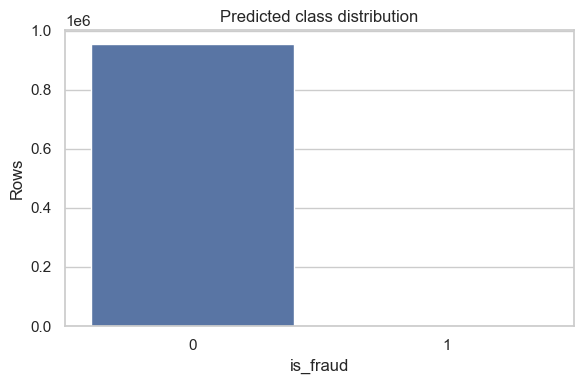

In [12]:
print("Submission preview")
display(submission.head())

prediction_distribution = submission[LABEL_COL].value_counts().rename("rows").to_frame()
prediction_distribution["ratio"] = submission[LABEL_COL].value_counts(normalize=True)
display(prediction_distribution)

plt.figure(figsize=(6, 4))
sns.barplot(
    x=prediction_distribution.index.astype(str), y=prediction_distribution["rows"]
)
plt.title("Predicted class distribution")
plt.xlabel(LABEL_COL)
plt.ylabel("Rows")
plt.tight_layout()
plt.show()


## Conclusion

This notebook keeps the workflow fully local and manual.

- It uses fraud-focused feature engineering instead of AutoML.
- It compares multiple models and tunes the threshold with macro F1.
- It checks both a stratified split and a time-aware split.
- It exports `submission_manual_ml.csv` so you can upload it yourself.

If the final model takes too long on your machine, reduce the negative caps first. The feature logic and threshold tuning can stay the same.
